# Challenge 002: diagnóstico e automação sob controle

## tl;dr

Este notebook executa o data audit e o experimento de classificação usados na solução. As conclusões são escritas somente após a execução:

- o Dataset 1 revela clientes reincidentes, mas não permite medir FRT, TTR, touch time ou ROI observado;
- o Dataset 2 sustenta uma prova técnica de classificação com validação de threshold e teste final;
- o protótipo deve operar em shadow mode, com decisão humana como padrão.

## Context & Methods

### Key Assumptions

1. Os arquivos públicos representam a operação da empresa fictícia dentro do exercício.
2. `First Response Time` e `Time to Resolution` precisam ser auditados antes de serem tratados como durações.
3. A taxonomia de suporte interno de TI não equivale à taxonomia de suporte ao cliente.
4. O threshold é escolhido na validação e avaliado uma vez no teste final.

In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
assert (ROOT / "scripts/data_audit.py").exists(), "Execute o notebook a partir da raiz do projeto."

## Data

### 1. Auditar os dois datasets

In [2]:
runpy.run_path(str(ROOT / "scripts/data_audit.py"), run_name="__main__")
audit = json.loads((ROOT / "artifacts/data_audit.json").read_text(encoding="utf-8"))
pd.DataFrame({
    "dataset": ["Suporte ao cliente", "Tickets de TI"],
    "linhas": [audit["dataset_1"]["rows"], audit["dataset_2"]["rows"]],
    "colunas": [audit["dataset_1"]["columns"], audit["dataset_2"]["columns"]],
})

{
  "dataset_1_rows": 8469,
  "dataset_1_negative_time_rate": 0.49295774647887325,
  "dataset_2_rows": 47837,
  "dataset_2_duplicate_document_rows": 0,
  "report": "docs/gate-1/data-audit.md"
}


,dataset,linhas,colunas
0,Suporte ao cliente,8469,17
1,Tickets de TI,47837,2


### 2. Verificar a integridade temporal do Dataset 1

In [3]:
d1 = audit["dataset_1"]
pd.DataFrame({
    "verificação": [
        "Pares com ambos os timestamps",
        "Resolução anterior à primeira resposta",
        "Descrições com placeholder",
        "Contatos repetidos sem solução",
        "CSAT disponível",
    ],
    "linhas": [
        d1["paired_timestamp_rows"],
        d1["negative_response_to_resolution_rows"],
        d1["placeholder_description_rows"],
        d1["repeated_unresolved_rows"],
        d1["rows"] - d1["null_counts"]["Customer Satisfaction Rating"],
    ],
})

,verificação,linhas
0,Pares com ambos os timestamps,2769
1,Resolução anterior à primeira resposta,1365
2,Descrições com placeholder,8469
3,Contatos repetidos sem solução,460
4,CSAT disponível,2769


**Interpretação:** não há timestamp de abertura. Quase metade dos pares possui ordem temporal impossível, e todas as descrições carregam placeholder. Ainda assim, 460 relatos de contatos repetidos sem solução sustentam uma fila de cuidado prioritário. O texto pode orientar ação; os campos temporais não sustentam horas economizadas observadas.

### 3. Treinar e avaliar o classificador no Dataset 2

In [4]:
runpy.run_path(str(ROOT / "scripts/train_classifier.py"), run_name="__main__")
metrics = json.loads((ROOT / "artifacts/classifier_metrics.json").read_text(encoding="utf-8"))
pd.DataFrame([
    {"modelo": "Baseline majoritário", "accuracy": metrics["baseline_final_test"]["accuracy"], "macro_f1": metrics["baseline_final_test"]["macro_f1"]},
    {"modelo": "TF-IDF + LinearSVC calibrado", "accuracy": metrics["model_final_test"]["accuracy"], "macro_f1": metrics["model_final_test"]["macro_f1"]},
])

{
  "metrics": {
    "data": {
      "rows": 47837,
      "train_rows": 33485,
      "threshold_validation_rows": 7176,
      "final_test_rows": 7176,
      "classes": [
        "Access",
        "Administrative rights",
        "HR Support",
        "Hardware",
        "Internal Project",
        "Miscellaneous",
        "Purchase",
        "Storage"
      ],
      "random_state": 42,
      "split": "stratified 70/15/15; threshold selected only on validation; normalized documents are unique in the source audit"
    },
    "baseline_final_test": {
      "strategy": "always predict Hardware",
      "accuracy": 0.2846989966555184,
      "macro_f1": 0.055401887406443216
    },
    "model_final_test": {
      "name": "word 1-2 gram TF-IDF + class-balanced LinearSVC + sigmoid calibration",
      "accuracy": 0.8666387959866221,
      "balanced_accuracy": 0.8534492624563379,
      "macro_f1": 0.8681460743761571,
      "weighted_f1": 0.8667165133826494,
      "ece_10_bins": 0.04863514036786656

,modelo,accuracy,macro_f1
0,Baseline majoritário,0.284699,0.055402
1,TF-IDF + LinearSVC calibrado,0.866639,0.868146


## Results

### 4. Avaliar cobertura versus acurácia

,threshold,coverage,covered_tickets,accuracy_when_covered,macro_f1_when_covered,errors_when_covered,split
0,0.50,0.933110,6696,0.896207,0.898858,695,threshold_validation
1,0.55,0.888099,6373,0.914012,0.916004,548,threshold_validation
2,0.60,0.844203,6058,0.927699,0.931315,438,threshold_validation
3,0.65,0.797938,5726,0.939574,0.942353,346,threshold_validation
4,0.70,0.750836,5388,0.949889,0.951533,270,threshold_validation
5,0.75,0.700530,5027,0.960215,0.961227,200,threshold_validation
6,0.80,0.644509,4625,0.971459,0.972037,132,threshold_validation
7,0.85,0.574833,4125,0.979879,0.979334,83,threshold_validation
8,0.90,0.467949,3358,0.988982,0.990153,37,threshold_validation
9,0.95,0.303094,2175,0.995402,0.996587,10,threshold_validation


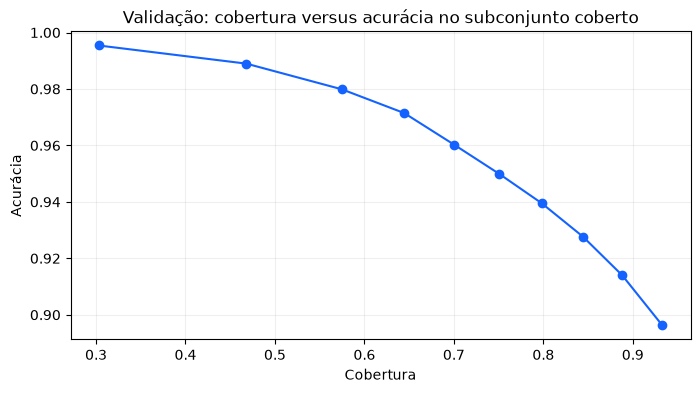

In [5]:
thresholds = pd.read_csv(ROOT / "artifacts/tables/classifier_coverage_accuracy.csv")
display(thresholds)

ax = thresholds.plot(
    x="coverage",
    y="accuracy_when_covered",
    marker="o",
    legend=False,
    figsize=(8, 4),
    color="#1463ff",
)
ax.set_title("Validação: cobertura versus acurácia no subconjunto coberto")
ax.set_xlabel("Cobertura")
ax.set_ylabel("Acurácia")
ax.grid(alpha=0.2)
plt.show()

### 5. Inspecionar desempenho por classe

In [6]:
per_class = pd.read_csv(ROOT / "artifacts/tables/classifier_per_class_metrics.csv")
per_class[~per_class["class"].isin(["accuracy", "macro avg", "weighted avg"])].sort_values("f1-score")

,class,precision,recall,f1-score,support
1,Administrative rights,0.864865,0.727273,0.790123,264.0
5,Miscellaneous,0.827425,0.837583,0.832473,1059.0
3,Hardware,0.833099,0.869799,0.851054,2043.0
4,Internal Project,0.890728,0.845912,0.867742,318.0
2,HR Support,0.871966,0.877825,0.874886,1637.0
7,Storage,0.926396,0.877404,0.901235,416.0
0,Access,0.906692,0.899906,0.903286,1069.0
6,Purchase,0.959302,0.891892,0.924370,370.0


### 6. Cruzar as duas filas sem misturar taxonomias

In [7]:
runpy.run_path(str(ROOT / "scripts/cross_dataset_audit.py"), run_name="__main__")
cross = json.loads((ROOT / "artifacts/cross_dataset_audit.json").read_text(encoding="utf-8"))
pd.DataFrame({
    "medida": [
        "Mensagens de clientes analisadas",
        "Acima do threshold de TI",
        "Concentradas em Hardware",
        "Sinalizadas para cuidado humano",
    ],
    "resultado": [
        cross["dataset_1_rows_scored"],
        f'{cross["confidence"]["share_at_or_above_threshold"]:.1%}',
        f'{cross["largest_category_share"]:.1%}',
        f'{cross["customer_care"]["share"]:.1%}',
    ],
})

{
  "dataset_1_rows_scored": 8469,
  "dataset_2_model_sha256": "1e543f7bc80492b591c7c66f53610b2ac686d41edae61f769c237c24e40a7340",
  "threshold": 0.75,
  "confidence": {
    "median": 0.7469190628711164,
    "p90": 0.9023371519239498,
    "share_at_or_above_threshold": 0.4950997756523793
  },
  "predicted_categories": {
    "Hardware": 7203,
    "Miscellaneous": 207,
    "Administrative rights": 149,
    "Access": 788,
    "HR Support": 75,
    "Internal Project": 14,
    "Storage": 29,
    "Purchase": 4
  },
  "largest_category_share": 0.8505136379737868,
  "customer_care": {
    "rows": 1574,
    "share": 0.18585429212421772,
    "signal_counts": {
      "UNRESOLVED_OR_REPEAT_CONTACT": 463,
      "FINANCIAL_HARM": 693,
      "CANCELLATION_OR_CHURN": 489,
      "STRONG_DISSATISFACTION": 3,
      "SAFETY_PRIVACY_OR_ABUSE": 2
    }
  },
  "interpretation": "Exploratory out-of-domain application. Dataset 1 has no labels compatible with the Dataset 2 taxonomy, so accuracy is unknown."
}


,medida,resultado
0,Mensagens de clientes analisadas,8469
1,Acima do threshold de TI,49.5%
2,Concentradas em Hardware,85.1%
3,Sinalizadas para cuidado humano,18.6%


## Takeaways

1. **O maior achado do cliente é acionável:** 460 relatos indicam contatos repetidos sem solução.
2. **A prova técnica é válida dentro do Dataset 2:** o threshold foi escolhido na validação e reportado uma vez no teste final.
3. **As taxonomias não podem ser misturadas:** 85,1% das mensagens de clientes viraram Hardware no teste cruzado.
4. **A melhor decisão é shadow mode:** mostrar classificação, cuidado, confiança e abstenção sem executar ações externas.
5. **ROI permanece parametrizado:** volume elegível, touch time, adoção, revisão e custos precisam ser medidos.
6. **Próximo gate:** validar o protótipo e submeter claims e limitações ao revisor independente.